In [11]:
import pathlib

import numpy as np
import matplotlib.pyplot as plt

import openmc
import openmc.stats

In [12]:
openmc.reset_auto_ids()

detection_sph = openmc.Sphere(r=5.0)
outer_sph = openmc.Sphere(r=25.0, boundary_type='vacuum')
detection_cell = openmc.Cell(region=-detection_sph)
outer_cell = openmc.Cell(region=+detection_sph & -outer_sph)
geometry = openmc.Geometry(openmc.Universe(cells=[detection_cell, outer_cell]))

source = openmc.IndependentSource(
    space=openmc.stats.Point((0.0, 0.0, 10.0)),
    energy=openmc.stats.Discrete([14.0e6], [1.0]),
    angle=openmc.stats.Isotropic(),
)

flux_tally = openmc.Tally(name='sphere_flux')
flux_tally.filters = [openmc.CellFilter(detection_cell)]
flux_tally.scores = ['flux']

PARTICLES_PER_BATCH = 100
BATCH_CHECKPOINTS = [100, 1000, 10000]

settings = openmc.Settings()
settings.run_mode = 'fixed source'
settings.particles = PARTICLES_PER_BATCH
settings.batches = BATCH_CHECKPOINTS[-1]
settings.seed = 1
settings.source = source
settings.statepoint = {'batches': BATCH_CHECKPOINTS}
settings.output = {'tallies': False}

model = openmc.Model(
    geometry=geometry,
    settings=settings,
    tallies=openmc.Tallies([flux_tally]),
)

In [13]:
RUN_DIR = pathlib.Path('test1_outputs')
RUN_DIR.mkdir(exist_ok=True)
model.export_to_model_xml(path=RUN_DIR)

In [14]:
model.run(cwd=RUN_DIR, output=False)

PosixPath('/mnt/c/Users/kosbor/programs/openmc-tests-structure/0.15.3/fundamental_testing/7221_se/test1_outputs/statepoint.10000.h5')

In [15]:
Ns = np.array(BATCH_CHECKPOINTS) * PARTICLES_PER_BATCH
std_devs = []
rel_errs = []

for batch in BATCH_CHECKPOINTS:
    sp_path = RUN_DIR / f'statepoint.{batch:0{len(str(BATCH_CHECKPOINTS[-1]))}d}.h5'
    with openmc.StatePoint(sp_path) as sp:
        tally = sp.get_tally(name='sphere_flux')
        mean = float(tally.mean.ravel()[0])
        std_dev = float(tally.std_dev.ravel()[0])
    std_devs.append(std_dev)
    rel_errs.append(std_dev / mean if mean > 0 else float('nan'))

std_devs = np.array(std_devs)
rel_errs = np.array(rel_errs)

In [16]:
ref_ratio = np.sqrt(Ns[0] / Ns)
actual_ratio = std_devs / std_devs[0]
TOLERANCE = 0.5

overall_pass = bool(
    np.all(np.isfinite(rel_errs))
    and np.all(std_devs > 0)
    and np.all(np.diff(std_devs) < 0)
    and np.all(np.abs(actual_ratio - ref_ratio) < TOLERANCE * ref_ratio)
)

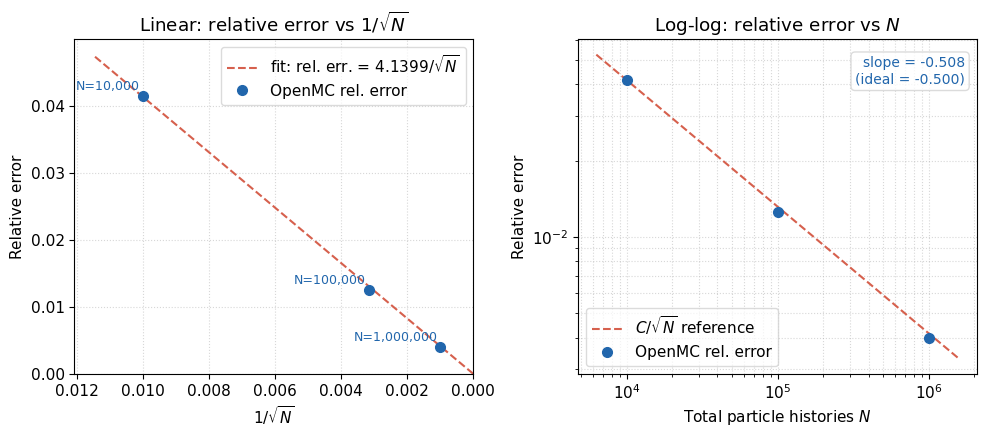

In [17]:
N_ref = np.logspace(np.log10(Ns[0]) - 0.2, np.log10(Ns[-1]) + 0.2, 200)
re_ref = rel_errs[0] * np.sqrt(Ns[0] / N_ref)
inv_sqrt_N = 1.0 / np.sqrt(Ns)
slope_fit = np.dot(inv_sqrt_N, rel_errs) / np.dot(inv_sqrt_N, inv_sqrt_N)
inv_sqrt_N_ref = np.linspace(0, inv_sqrt_N[0] * 1.15, 200)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
ax = axes[0]
ax.plot(inv_sqrt_N_ref, slope_fit * inv_sqrt_N_ref, color='#d6604d', ls='--',
        label=f'fit: rel. err. = {slope_fit:.4f}/$\\sqrt{{N}}$')
ax.plot(inv_sqrt_N, rel_errs, 'o', color='#2166ac', ms=7, label='OpenMC rel. error')
for count, x, error in zip(Ns, inv_sqrt_N, rel_errs):
    ax.annotate(f'N={count:,.0f}', xy=(x, error), xytext=(-2, 4),
                textcoords='offset points', fontsize=9, color='#2166ac', ha='right')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xlabel(r'$1/\sqrt{N}$')
ax.set_ylabel('Relative error')
ax.set_title(r'Linear: relative error vs $1/\sqrt{N}$')
ax.invert_xaxis()
ax.legend()
ax.grid(True, ls=':', alpha=0.5)

ax = axes[1]
ax.loglog(N_ref, re_ref, color='#d6604d', ls='--', label=r'$C/\sqrt{N}$ reference')
ax.loglog(Ns, rel_errs, 'o', color='#2166ac', ms=7, label='OpenMC rel. error')
log_slope = np.polyfit(np.log10(Ns), np.log10(rel_errs), 1)[0]
ax.text(0.97, 0.95, f'slope = {log_slope:.3f}\n(ideal = -0.500)',
        transform=ax.transAxes, ha='right', va='top', fontsize=10, color='#2166ac',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='lightgrey', alpha=0.8))
ax.set_xlabel('Total particle histories $N$')
ax.set_ylabel('Relative error')
ax.set_title(r'Log-log: relative error vs $N$')
ax.legend()
ax.grid(True, which='both', ls=':', alpha=0.5)

fig.tight_layout()
plt.savefig('7221_se_1.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
result = 'PASS' if overall_pass else 'FAIL'
with open('results.txt', 'w') as results_file:
    results_file.write(result + '\n')